# Session 4

Introduction to Neural Networks



---



Michael de la Maza

AI/ML

Hult International business School

Adapted from "Data Mining for Business Analytics" by Shmueli

## Simple Dataset: MLPClassifier

In [37]:
# Extremely simple dataset example

import numpy as np
import pandas as pd

# 5 minute exercise - What pattern do you see in this dataset?
# Draw graph

creditcard_df = pd.DataFrame({
    'Years': [4, 18, 1, 3, 15, 6], # years with credit
    'Salary': [43, 65, 53, 95, 88, 112], # salary
    'Used_credit': [0, 1, 0, 0, 1, 1], # 1=unpaid credit card balance at end of month
})

input_df = creditcard_df.drop(columns=['Used_credit'])
output_df = creditcard_df.Used_credit

X = np.array(input_df)
y = np.array(output_df)

# We will not split into training and test sets

print(X)
print(y)




[[  4  43]
 [ 18  65]
 [  1  53]
 [  3  95]
 [ 15  88]
 [  6 112]]
[0 1 0 0 1 1]


In [38]:
# Train neural net with single hidden layer

from sklearn.neural_network import MLPClassifier # MLP = multilayer perceptron

# Single hidden layer with 3 neurons
# Example: hidden_layer_sizes = (3, 4). Two hidden layers with 3 and 4 neurons.
clf = MLPClassifier(hidden_layer_sizes=(3), activation='logistic', solver='lbfgs', random_state=42)
clf.fit(X, y) # input and output layer automatically determined by data

# 5 minute exercise - (1) Draw this neural net. (2) How many weights and biases does it have?

# Network structure
for i, (weights, intercepts) in enumerate(zip(clf.coefs_, clf.intercepts_)):
    print('Hidden layer' if i == 0 else 'Output layer')
    print(' Intercepts/Biases:\n ', intercepts)
    print(' Weights:')
    for weight in weights:
        print(' ', weight)
    print()

print(clf.out_activation_) # Note: Output node is logistic.

Hidden layer
 Intercepts/Biases:
  [0.46227885 0.46324141 0.12788667]
 Weights:
  [-3.58370709  0.4981063   0.25621391]
  [ 0.55615455 -0.37742993 -0.38062656]

Output layer
 Intercepts/Biases:
  [7.7861758]
 Weights:
  [-8.88306107]
  [-0.59218753]
  [0.58033071]

logistic


In [39]:
# Print predictions

print(pd.concat([
    creditcard_df,
    pd.DataFrame(clf.predict_proba(X), columns=[0, 1])
], axis=1))

# How many does it get right? How many does it get wrong? (assume cutoff of 0.5)

   Years  Salary  Used_credit         0         1
0      4      43            0  0.749604  0.250396
1     18      65            1  0.000415  0.999585
2      1      53            0  0.749676  0.250324
3      3      95            0  0.749676  0.250324
4     15      88            1  0.000465  0.999535
5      6     112            1  0.749676  0.250324


In [40]:
# Neural network description

print('Output nodes:', clf.n_outputs_)
print('Number of layers:', clf.n_layers_)
print('Number of features:', clf.n_features_in_)
print('Classes', clf.classes_)


Output nodes: 1
Number of layers: 3
Number of features: 2
Classes [0 1]


In [41]:
# Inputs to neural networks should (almost) always be scaled
# But we didn't do that!

from sklearn.preprocessing import StandardScaler

# StandardScaler = z score. Mean = 0, std = 1.

scaler = StandardScaler()
scaled_features = scaler.fit_transform(creditcard_df[['Years', 'Salary']])

# Print the scaled features
print(scaled_features)


[[-0.60255689 -1.3585885 ]
 [ 1.59808568 -0.45286283]
 [-1.07412316 -0.94689502]
 [-0.75974565  0.78221762]
 [ 1.12651941  0.49403218]
 [-0.28817938  1.48209655]]


In [42]:
# Reset input X

X = scaled_features

print(X)
print(y)

[[-0.60255689 -1.3585885 ]
 [ 1.59808568 -0.45286283]
 [-1.07412316 -0.94689502]
 [-0.75974565  0.78221762]
 [ 1.12651941  0.49403218]
 [-0.28817938  1.48209655]]
[0 1 0 0 1 1]


In [43]:
# Retrain neural network

clf = MLPClassifier(hidden_layer_sizes=(2,3), activation='logistic', solver='lbfgs', random_state=42)
clf.fit(X, y)

# Network structure
for i, (weights, intercepts) in enumerate(zip(clf.coefs_, clf.intercepts_)):
    print('Hidden layer' if i == 0 else 'Output layer')
    print(' Intercepts:\n ', intercepts)
    print(' Weights:')
    for weight in weights:
        print(' ', weight)
    print()

Hidden layer
 Intercepts:
  [-0.81645287 -1.13879953]
 Weights:
  [1.95670508 4.30468966]
  [1.36418563 2.98598857]

Output layer
 Intercepts:
  [-2.06859051  2.86654544 -3.78117638]
 Weights:
  [-0.71936985 -1.680848    2.86255405]
  [-2.00502963 -4.77299444  5.57435524]

Output layer
 Intercepts:
  [-0.17402207]
 Weights:
  [0.3561377]
  [-8.74216585]
  [8.88556704]



In [44]:
# Print predictions
# Notice that predictions have improved for class 0

print(pd.concat([
    creditcard_df,
    pd.DataFrame(clf.predict_proba(X), columns=[0, 1])
], axis=1))

# How many does it get right? How many does it get wrong?

   Years  Salary  Used_credit         0         1
0      4      43            0  0.999720  0.000280
1     18      65            1  0.000260  0.999740
2      1      53            0  0.999722  0.000278
3      3      95            0  0.999207  0.000793
4     15      88            1  0.000247  0.999753
5      6     112            1  0.000490  0.999510


In [ ]:
# 5 minute exercise

# Train a neural network with two hidden layers. The first has two neurons and the second has 3 neurons.
# How does it perform?

## Car dataset: MLPRegressor

In [45]:
!pip install dmba

import dmba



In [46]:
# load the data
car_df = dmba.load_data('ToyotaCorolla.csv')

print(car_df.head())

# select some of the variables
selected_var = ['Price', 'Age_08_04', 'KM', 'Fuel_Type', 'HP', 'Automatic', 'Doors', 'Quarterly_Tax',
                'Mfr_Guarantee', 'Guarantee_Period', 'Airco', 'Automatic_airco', 'CD_Player',
                'Powered_Windows', 'Sport_Model', 'Tow_Bar']
car_df = car_df[selected_var]


   Id                                          Model  Price  Age_08_04  \
0   1  TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors  13500         23   
1   2  TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors  13750         23   
2   3  TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors  13950         24   
3   4  TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors  14950         26   
4   5    TOYOTA Corolla 2.0 D4D HATCHB SOL 2/3-Doors  13750         30   

   Mfg_Month  Mfg_Year     KM Fuel_Type  HP  Met_Color  ... Powered_Windows  \
0         10      2002  46986    Diesel  90          1  ...               1   
1         10      2002  72937    Diesel  90          1  ...               0   
2          9      2002  41711    Diesel  90          1  ...               0   
3          7      2002  48000    Diesel  90          0  ...               0   
4          3      2002  38500    Diesel  90          0  ...               1   

   Power_Steering  Radio  Mistlamps  Sport_Model  Backseat_Divider  \
0         

In [47]:
print(car_df.describe())

              Price    Age_08_04             KM           HP    Automatic  \
count   1436.000000  1436.000000    1436.000000  1436.000000  1436.000000   
mean   10730.824513    55.947075   68533.259749   101.502089     0.055710   
std     3626.964585    18.599988   37506.448872    14.981080     0.229441   
min     4350.000000     1.000000       1.000000    69.000000     0.000000   
25%     8450.000000    44.000000   43000.000000    90.000000     0.000000   
50%     9900.000000    61.000000   63389.500000   110.000000     0.000000   
75%    11950.000000    70.000000   87020.750000   110.000000     0.000000   
max    32500.000000    80.000000  243000.000000   192.000000     1.000000   

             Doors  Quarterly_Tax  Mfr_Guarantee  Guarantee_Period  \
count  1436.000000    1436.000000    1436.000000       1436.000000   
mean      4.033426      87.122563       0.409471          3.815460   
std       0.952677      41.128611       0.491907          3.011025   
min       2.000000      19

In [48]:
# Neural networks don't work with categorical variables like Fuel_Type
# They must be converted
# pd.get_dummies converts categorical variables to 0/1 variables, one for each category
# Also called one hot encoding
# Note: Cannot run this code twice
car_df = pd.get_dummies(car_df, columns=['Fuel_Type'], drop_first=True)

# Define input and output variables
X_df = car_df.drop(columns=['Price'])
Y_df = car_df[ ['Price'] ] # Predicting Price



In [49]:
# Scale the data between 0 and 1 (similar to bike sales dataset)

from sklearn.preprocessing import MinMaxScaler

print(X_df.head())

scaleInput = MinMaxScaler()
scaleOutput = MinMaxScaler()
X = scaleInput.fit_transform(X_df)
y = scaleOutput.fit_transform(Y_df)

print(X[0:2])

   Age_08_04     KM  HP  Automatic  Doors  Quarterly_Tax  Mfr_Guarantee  \
0         23  46986  90          0      3            210              0   
1         23  72937  90          0      3            210              0   
2         24  41711  90          0      3            210              1   
3         26  48000  90          0      3            210              1   
4         30  38500  90          0      3            210              1   

   Guarantee_Period  Airco  Automatic_airco  CD_Player  Powered_Windows  \
0                 3      0                0          0                1   
1                 3      1                0          1                0   
2                 3      0                0          0                0   
3                 3      0                0          0                0   
4                 3      1                0          0                1   

   Sport_Model  Tow_Bar  Fuel_Type_Diesel  Fuel_Type_Petrol  
0            0        0             

In [50]:
# Create training and testing data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape


((861, 16), (575, 16), (861, 1), (575, 1))

Neural network with two neurons in one hidden layer

In [51]:
# This is a regression problem. Predicting Price.

from sklearn.neural_network import MLPRegressor

car_nnet = MLPRegressor(hidden_layer_sizes=(2), activation='logistic', solver='lbfgs', random_state=42)
car_nnet.fit(X_train, y_train.ravel()) # ravel flattens array

MLPRegressor(activation='logistic', hidden_layer_sizes=2, random_state=42,
             solver='lbfgs')

In [52]:
from sklearn.metrics import root_mean_squared_error, r2_score

# Reverse scaling
y_actual = scaleOutput.inverse_transform(y_train.reshape(-1, 1)).ravel()
y_pred = scaleOutput.inverse_transform(car_nnet.predict(X_train).reshape(-1, 1)).ravel()

rmse_train = root_mean_squared_error(y_actual, y_pred)

print("RMSE on training set: ", rmse_train)
print("R2 on training set", r2_score(y_actual, y_pred))

RMSE on training set:  1114.4642992388146
R2 on training set 0.9078670290555934


In [53]:
from sklearn.metrics import root_mean_squared_error, r2_score

# Reverse scaling
y_actual = scaleOutput.inverse_transform(y_test.reshape(-1, 1)).ravel()
y_pred = scaleOutput.inverse_transform(car_nnet.predict(X_test).reshape(-1, 1)).ravel()


rmse_test = root_mean_squared_error(y_actual, y_pred)

print("RMSE on test set: ", rmse_test)
print("R2 on test set", r2_score(y_actual, y_pred))

RMSE on test set:  1120.431643321363
R2 on test set 0.9006892444511346


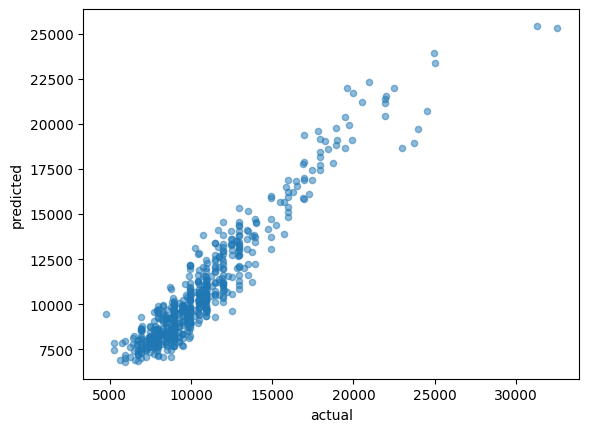

In [54]:
# Plot predicted vs actual values
import matplotlib.pylab as plt

ax = pd.DataFrame({'actual': y_actual, 'predicted': y_pred}).plot.scatter(x='actual', y='predicted', alpha=0.5)


plt.show()

In [55]:
# 5 minute exercise

# Look at the list of metrics.
# Select one that you think would be relevant.
# Add it to the code above.

In [56]:
# We have now trained a simple regressor on this dataset
# Now let's change the neural network hyperparameters and see if it makes a difference



Neural network with five neurons in one hidden layer

In [57]:
# train neural network with 5 hidden nodes
car_nnet = MLPRegressor(hidden_layer_sizes=(5), activation='logistic', solver='lbfgs', random_state=42)
car_nnet.fit(X_train, y_train.ravel())


MLPRegressor(activation='logistic', hidden_layer_sizes=5, random_state=42,
             solver='lbfgs')

In [58]:
# RMSE and R2 on the training set

# Reverse
y_actual = scaleOutput.inverse_transform(y_train.reshape(-1, 1)).ravel()
y_pred = scaleOutput.inverse_transform(car_nnet.predict(X_train).reshape(-1, 1)).ravel()


rmse_train = root_mean_squared_error(y_actual, y_pred)

print("RMSE on training set: ", rmse_train)
print("R2 on training set", r2_score(y_actual, y_pred))

RMSE on training set:  1137.0713238155324
R2 on training set 0.9040912638231079


In [59]:
# Calculate RMSE and R2 on the test set

# Inverse
y_actual = scaleOutput.inverse_transform(y_test.reshape(-1, 1)).ravel()
y_pred = scaleOutput.inverse_transform(car_nnet.predict(X_test).reshape(-1, 1)).ravel()

rmse_test = root_mean_squared_error(y_actual, y_pred)

print("RMSE on test set: ", rmse_test)
print("R2 on test set", r2_score(y_actual, y_pred))

RMSE on test set:  1150.6117607063297
R2 on test set 0.8952670896339638


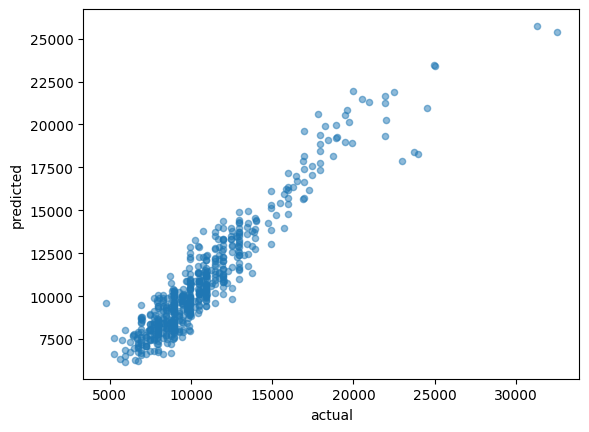

In [60]:
# Plot predicted versus actual prices
ax = pd.DataFrame({'actual': y_actual, 'predicted': y_pred}).plot.scatter(x='actual', y='predicted', alpha=0.5)
plt.show()

Neural network with one neuron in one hidden layer

In [61]:
car_nnet = MLPRegressor(hidden_layer_sizes=(), activation='logistic', solver='lbfgs', random_state=42)
car_nnet.fit(X_train, y_train.ravel())

MLPRegressor(activation='logistic', hidden_layer_sizes=(), random_state=42,
             solver='lbfgs')

In [62]:
# RMSE and R2 on the training set

# Reverse
y_actual = scaleOutput.inverse_transform(y_train.reshape(-1, 1)).ravel()
y_pred = scaleOutput.inverse_transform(car_nnet.predict(X_train).reshape(-1, 1)).ravel()

rmse_train = root_mean_squared_error(y_actual, y_pred)

print("RMSE on training set: ", rmse_train)
print("R2 on training set", r2_score(y_actual, y_pred))

RMSE on training set:  1203.4088663809628
R2 on training set 0.8925740586672005


In [63]:
print(car_nnet.n_layers_)

2


In [64]:
# Calculate RMSE and R2 on the test set

# Inverse
y_actual = scaleOutput.inverse_transform(y_test.reshape(-1, 1)).ravel()
y_pred = scaleOutput.inverse_transform(car_nnet.predict(X_test).reshape(-1, 1)).ravel()

rmse_test = root_mean_squared_error(y_actual, y_pred)

print("RMSE on test set: ", rmse_test)
print("R2 on test set", r2_score(y_actual, y_pred))

RMSE on test set:  1219.2260464768328
R2 on test set 0.8824036022395355


In [ ]:
# Plot predicted versus actual prices
ax = pd.DataFrame({'actual': y_actual, 'predicted': y_pred}).plot.scatter(x='actual', y='predicted', alpha=0.5)
plt.show()

In [ ]:
# Conclusion: For this particular dataset, we get very good performance (R2 = 0.9)
# with a very simple neural network (one neuron in the hidden layer). Changing the number of neurons does not
# impact the performance by much.



In [ ]:
# The End
